## Imports & config

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd()
if not (ROOT / "final_data").exists() and (ROOT.parent / "final_data").exists():
    ROOT = ROOT.parent

FINAL_DATA_DIR = ROOT / "final_data"
SPLIT_FOLDERS = {
    "train": "train",
    "val": "validate",
    "test": "test",
}
SPLIT_CSVS = {
    "train": ROOT / "train.csv",
    "val": ROOT / "val.csv",
    "test": ROOT / "test.csv",
}

LABELS = [
    "No gesture",
    "Swiping Down",
    "Swiping Left",
    "Swiping Right",
    "Swiping Up",
    "Turning Hand Clockwise",
    "Turning Hand Counterclockwise",
    "Zooming In With Two Fingers",
    "Zooming Out With Two Fingers",
]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

NUM_FRAMES = 37
INPUT_SIZE = 63
NUM_CLASSES = len(LABELS)
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 7
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Dataset

In [2]:
class GestureDataset(Dataset):
    def __init__(self, split):
        folder = SPLIT_FOLDERS[split]
        data_dir = FINAL_DATA_DIR / folder
        metadata = pd.read_csv(SPLIT_CSVS[split])

        self.samples = []
        for _, row in metadata.iterrows():
            video_id = int(row["video_id"])
            npy_path = data_dir / f"{video_id}.npy"
            if not npy_path.exists():
                continue
            self.samples.append(
                (npy_path, LABEL_TO_IDX[row["label"]])
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        npy_path, label = self.samples[idx]
        seq = np.load(npy_path).astype(np.float32)
        return torch.from_numpy(seq), torch.tensor(label, dtype=torch.long)


train_dataset = GestureDataset("train")
val_dataset = GestureDataset("val")
test_dataset = GestureDataset("test")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Train: 17605
Val:   2218
Test:  2197


## RNN model

In [3]:
class GestureRNN(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.rnn = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        outputs, (hidden, _) = self.rnn(x)
        last_hidden = hidden[-1]
        logits = self.classifier(self.dropout(last_hidden))
        return logits


model = GestureRNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(model)

Trainable parameters: 232,073
GestureRNN(
  (rnn): LSTM(63, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=9, bias=True)
)


## Training (early stopping on validation loss)

In [4]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for sequences, labels in loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(sequences)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer
    )
    val_loss, val_acc = run_epoch(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
model.to(device)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 01 | train loss 1.5571 acc 0.4571 | val loss 1.2675 acc 0.5600
Epoch 02 | train loss 0.8814 acc 0.7358 | val loss 0.6856 acc 0.7949
Epoch 03 | train loss 0.6802 acc 0.8013 | val loss 0.6262 acc 0.8170
Epoch 04 | train loss 0.5992 acc 0.8258 | val loss 0.7353 acc 0.7867
Epoch 05 | train loss 0.5777 acc 0.8333 | val loss 0.5597 acc 0.8345
Epoch 06 | train loss 0.5323 acc 0.8436 | val loss 0.5529 acc 0.8300
Epoch 07 | train loss 0.5106 acc 0.8522 | val loss 0.5291 acc 0.8395
Epoch 08 | train loss 0.4947 acc 0.8562 | val loss 0.5201 acc 0.8381
Epoch 09 | train loss 0.4761 acc 0.8605 | val loss 0.5022 acc 0.8521
Epoch 10 | train loss 0.4569 acc 0.8683 | val loss 0.4961 acc 0.8535
Epoch 11 | train loss 0.4527 acc 0.8689 | val loss 0.4814 acc 0.8535
Epoch 12 | train loss 0.4317 acc 0.8754 | val loss 0.4746 acc 0.8544
Epoch 13 | train loss 0.4154 acc 0.8796 | val loss 0.4401 acc 0.8697
Epoch 14 | train loss 0.4118 acc 0.8789 | val loss 0.5233 acc 0.8422
Epoch 15 | train loss 0.3989 acc 0

## Training curves

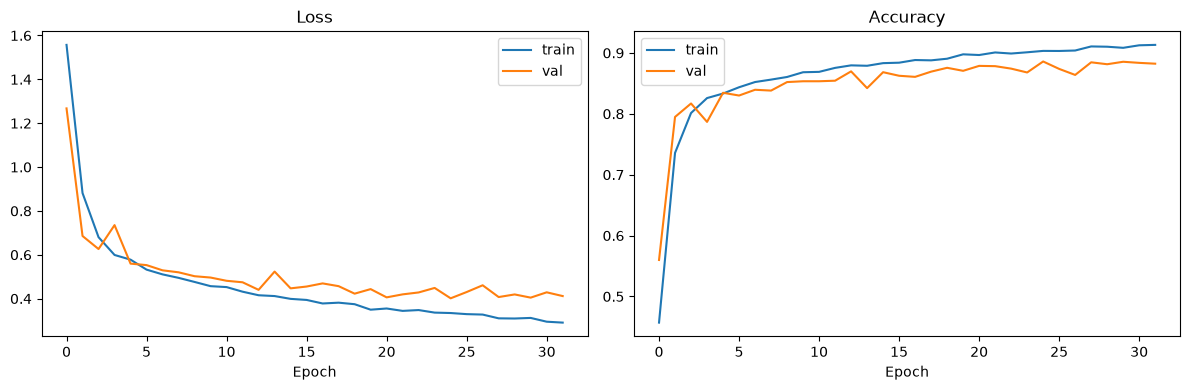

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Test evaluation

Test loss: 0.3969
Test accuracy: 0.8858

Classification report:
                               precision    recall  f1-score   support

                   No gesture     0.8441    0.9638    0.9000       719
                 Swiping Down     0.9179    0.8995    0.9086       199
                 Swiping Left     0.9081    0.9180    0.9130       183
                Swiping Right     0.9167    0.9322    0.9244       177
                   Swiping Up     0.9497    0.8854    0.9164       192
       Turning Hand Clockwise     0.8217    0.6928    0.7518       153
Turning Hand Counterclockwise     0.8636    0.7261    0.7889       157
  Zooming In With Two Fingers     0.9344    0.8301    0.8792       206
 Zooming Out With Two Fingers     0.9326    0.8531    0.8911       211

                     accuracy                         0.8858      2197
                    macro avg     0.8988    0.8557    0.8748      2197
                 weighted avg     0.8880    0.8858    0.8842      2197



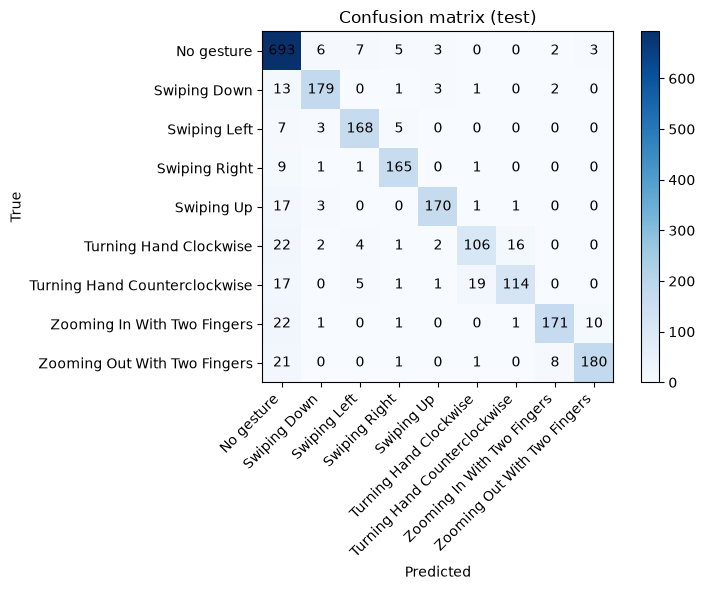

In [6]:
test_loss, test_acc = run_epoch(test_loader, model, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        logits = model(sequences)
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), LABELS, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()